In [1]:
import scapy.all as scapy
import numpy as np
import matplotlib.pyplot as plt

# 1. Leemos el archivo (iterando para no saturar la RAM)
pcap_file = "samba-realtime.pcap"
packets = scapy.PcapReader(pcap_file)

tiempos = []

# 2. Bucle
for pkt in packets:
    # Extraemos el atributo 'time' (el timestamp de llegada)
    # y lo guardamos en nuestra lista
    tiempos.append(float(pkt.time))

# 3. Convertimos a tiempos relativos (empezando desde 0)
tiempos = np.array(tiempos)
tiempos_relativos = tiempos - tiempos[0]

# 4. Agrupamos por segundos (Histograma)
# Queremos saber: ¿Cuántos paquetes hay en el segundo 1? ¿Y en el 2?
segundos_totales = int(np.ceil(tiempos_relativos.max()))
counts, bins = np.histogram(tiempos_relativos, bins=range(segundos_totales + 1))

print(f"He analizado {len(tiempos)} paquetes en {segundos_totales} segundos.")

He analizado 45819 paquetes en 1783 segundos.


In [2]:
import pandas as pd
#Data frame con tiempo en formato Unix Epoch
df_timestamp = pd.DataFrame({'time_stamp' : tiempos, 'valor' : 1})
# Convertimos el Unix Epoch a objetos datetime de Pandas
df_timestamp['hora_completa'] = pd.to_datetime(df_timestamp['time_stamp'], unit='s')

# Creamos la columna con el formato exacto [HH:MM:SS] que me pediste
df_timestamp['formato_24h'] = df_timestamp['hora_completa'].dt.strftime('[%H:%M:%S]')

# Calculamos también el tiempo relativo (segundos desde el inicio) 
df_timestamp['tiempo_relativo'] = df_timestamp['time_stamp'] - df_timestamp['time_stamp'].iloc[0]

print(df_timestamp[['time_stamp', 'formato_24h', 'tiempo_relativo']].head())

     time_stamp formato_24h  tiempo_relativo
0  1.772623e+09  [11:23:07]         0.000000
1  1.772623e+09  [11:23:07]         0.000039
2  1.772623e+09  [11:23:07]         0.000562
3  1.772623e+09  [11:23:07]         0.000994
4  1.772623e+09  [11:23:07]         0.001018


In [3]:
import pandas as pd
#Crear un DataFrame para manejarlo como una serie temporal
df = pd.DataFrame({'tiempo': tiempos_relativos, 'valor': 1})
df.head()

,tiempo,valor
0,0.000000,1
1,0.000039,1
2,0.000562,1
3,0.000994,1
4,0.001018,1


In [4]:
# 1. Redondeamos el tiempo de cada paquete al segundo más cercano
# Si un paquete llegó en el 1.2s y otro en el 1.8s, ambos van al "Segundo 1"
df['segundo'] = df['tiempo'].astype(int)

# 2. Agrupamos por ese segundo y contamos cuántos hay
# "Dime cuántas filas hay para el Segundo 1, cuántas para el Segundo 2..."
df_resampled = df.groupby('segundo').size().reset_index(name='pps')

print(df_resampled.tail(60)) # Aquí verás: Segundo 0 -> 25 paquetes, Segundo 1 -> 22...

      segundo  pps
1586     1720   26
1587     1721    2
1588     1722   10
1589     1723   16
1590     1724   14
1591     1725   18
1592     1726   10
1593     1727   10
1594     1728    2
1595     1729    7
1596     1730    7
1597     1731   20
1598     1732    2
1599     1734   24
1600     1735   18
1601     1736   20
1602     1737   12
1603     1738   28
1604     1739   12
1605     1740   28
1606     1741   10
1607     1742    4
1608     1743   14
1609     1744   10
1610     1745   30
1611     1746   10
1612     1747   13
1613     1748   17
1614     1749   26
1615     1750   10
1616     1751    4
1617     1752   30
1618     1753   20
1619     1754   10
1620     1755   20
1621     1756   28
1622     1758   18
1623     1759   32
1624     1760   38
1625     1761   10
1626     1762   10
1627     1763    2
1628     1764   11
1629     1765   20
1630     1766   32
1631     1767   20
1632     1769   18
1633     1770    8
1634     1771   20
1635     1772    4
1636     1773   22
1637     177

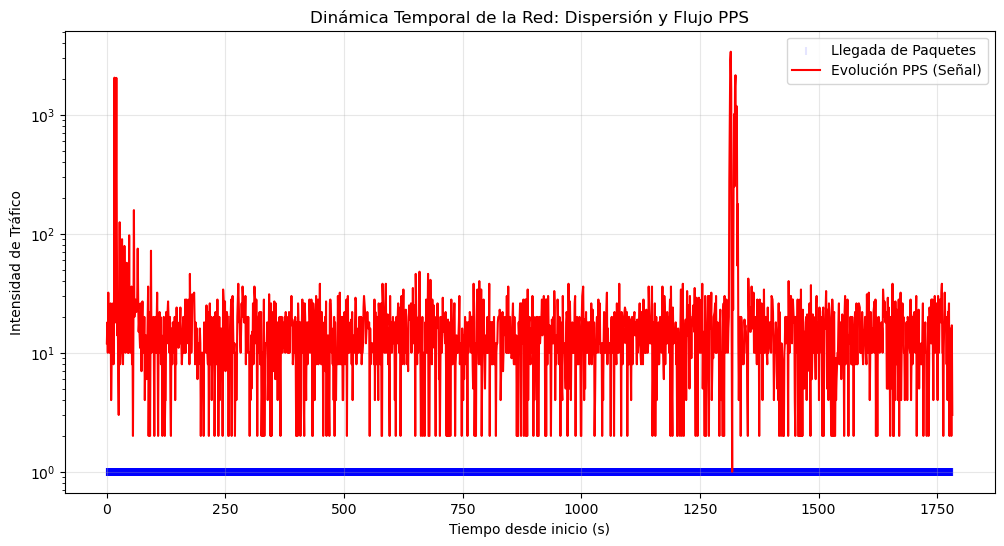

In [5]:
# Pintar la Dispersión
plt.figure(figsize=(12, 6))

# Pintamos cada paquete como un pequeño punto (dispersión)
plt.scatter(tiempos_relativos, np.ones_like(tiempos_relativos), 
            alpha=0.1, color='blue', marker='|', label='Llegada de Paquetes')

# Pintamos la línea de PPS (Paquetes por segundo) encima
plt.plot(df_resampled['segundo'], df_resampled['pps'], 
         color='red', linewidth=1.5, label='Evolución PPS (Señal)')

plt.title("Dinámica Temporal de la Red: Dispersión y Flujo PPS")
plt.xlabel("Tiempo desde inicio (s)")
plt.ylabel("Intensidad de Tráfico")
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

plt.show()

In [6]:
#Basándonos en esto defino el baseline entre 100 y 1200 segundos para tener buena estadística
media_pps = df_resampled['pps'][100:1200].mean()
std_pps = df_resampled['pps'][100:1200].std()
print(f'Media: {media_pps}\n Desviación: {std_pps}')

Media: 14.623636363636363
 Desviación: 8.403397719092341


In [7]:
# 1. Definimos umbral (esto ya lo tienes perfecto)
umbral_anomalia = media_pps + 3.0 * std_pps

# 2. IDENTIFICACIÓN DE MOMENTOS DE ATAQUE (Sobre el dataframe de SEGUNDOS)
# Usamos df_resampled porque es donde comparamos PPS vs Umbral
df_resampled['es_ataque'] = df_resampled['pps'] > umbral_anomalia
df_resampled['es_ataque'] = df_resampled['es_ataque'].fillna(False)

# 3. Filtramos los segundos culpables
ataques = df_resampled[df_resampled['es_ataque']]

# 4. Imprimimos los resultados limpios
print("--- Segundos con Tráfico Anómalo ---")
print(ataques[['segundo', 'pps']])

# 5. Lista de segundos únicos para tu informe
segundos_criticos = ataques['segundo'].tolist()
print(f"\n¡Anomalías críticas detectadas en los segundos: {segundos_criticos}!")

--- Segundos con Tráfico Anómalo ---
      segundo   pps
15         16  2050
18         20  2042
19         21   101
25         27   125
30         32    90
34         37    79
38         42    57
43         47    97
53         57   158
58         65    75
83         93    72
162       175    46
596       651    46
603       659    48
620       677    46
625       682    41
722       785    40
1209     1312   279
1210     1313   823
1211     1314  2898
1212     1315  3388
1213     1316  1626
1216     1319   148
1218     1321   276
1219     1322  1012
1220     1323   250
1221     1324  1740
1222     1325  2149
1223     1326   362
1224     1327  1187
1225     1328   716
1226     1329    54
1227     1330   178
1249     1352    42
1324     1437    40

¡Anomalías críticas detectadas en los segundos: [16, 20, 21, 27, 32, 37, 42, 47, 57, 65, 93, 175, 651, 659, 677, 682, 785, 1312, 1313, 1314, 1315, 1316, 1319, 1321, 1322, 1323, 1324, 1325, 1326, 1327, 1328, 1329, 1330, 1352, 1437]!


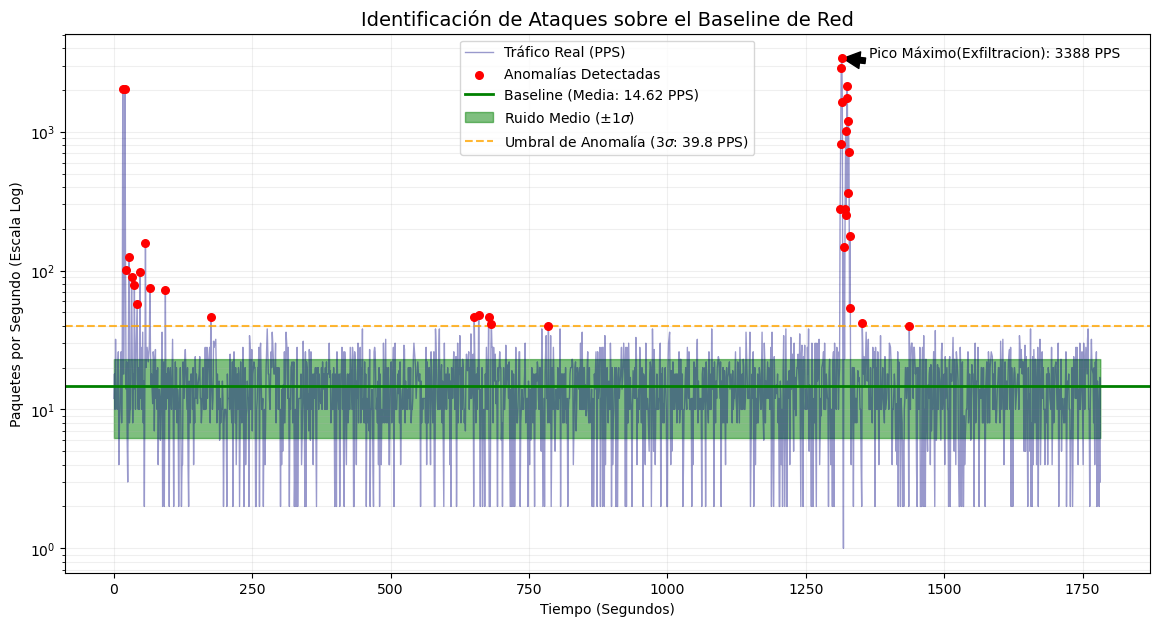

In [8]:
#EL DIBUJO
plt.figure(figsize=(14, 7))

# Pintamos todos los datos de la red (los normales y los ataques)
plt.plot(df_resampled['segundo'], df_resampled['pps'], color='navy', 
         label='Tráfico Real (PPS)', alpha=0.4, linewidth=1)

# Resaltamos los momentos identificados como 'ataques' con puntos rojos
plt.scatter(ataques['segundo'], ataques['pps'], color='red', 
            label='Anomalías Detectadas', zorder=5, s=30)

# Pintamos la Baseline (Media) y el Ruido (Desviación)
plt.axhline(y=media_pps, color='green', linestyle='-', 
            label=f'Baseline (Media: {media_pps:.2f} PPS)', linewidth=2)

# Sombreado de la zona de ruido medio (±1 sigma)
plt.fill_between(df_resampled['segundo'], media_pps - std_pps, media_pps + std_pps, 
                 color='green', alpha=0.5, label='Ruido Medio (±1$\sigma$)')

# Pintamos tu umbral de anomalia (3 sigmas)
plt.axhline(y=umbral_anomalia, color='orange', linestyle='--', 
            label=f'Umbral de Anomalía (3$\sigma$: {umbral_anomalia:.1f} PPS)', alpha=0.8)


# Usamos escala logarítmica 
plt.yscale('log')

# Títulos y etiquetas con tu estilo
plt.title('Identificación de Ataques sobre el Baseline de Red', fontsize=14)
plt.xlabel('Tiempo (Segundos)')
plt.ylabel('Paquetes por Segundo (Escala Log)')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(loc='upper center')

# Anotamos el pico máximo
pico_max_seg = ataques.loc[ataques['pps'].idxmax(), 'segundo']
pico_max_val = ataques['pps'].max()
plt.annotate(f'Pico Máximo(Exfiltracion): {pico_max_val} PPS', 
             xy=(pico_max_seg, pico_max_val), xytext=(pico_max_seg+50, pico_max_val),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)

plt.show()

In [9]:
# Vamos a comparar con la sonda:
import re
from datetime import datetime
log_data='''
[06:13:35]  Actividad interactiva: Posible Escaneo - Ráfaga: 14pkts/s
[06:13:50]  Actividad interactiva: Posible Escaneo - Ráfaga: 6pkts/s
[06:14:09]  Actividad interactiva: Posible Escaneo - Ráfaga: 9pkts/s
[06:15:56]   Actividad interactiva (Shell/Teclado) - Size: 4B
[06:16:16]  Actividad interactiva: Posible Escaneo - Ráfaga: 19pkts/s
[06:16:34]  Actividad interactiva: Posible Escaneo - Ráfaga: 9pkts/s
[06:23:34]   Actividad interactiva (Shell/Teclado) - Size: 4B
[06:23:54]  Actividad interactiva: Posible Escaneo - Ráfaga: 19pkts/s
[06:24:13]  Actividad interactiva: Posible Escaneo - Ráfaga: 9pkts/s
[06:26:37]  [ALERTA DPI] Firma detectada: '.war'
   [!] CRÍTICO: Intento de subida de artefacto JAVA (.war)
--------------------------------------------------
[06:29:28]   Actividad interactiva (Shell/Teclado) - Size: 3B
[06:29:39]   Actividad interactiva (Shell/Teclado) - Size: 3B
[06:33:43]   Actividad interactiva (Shell/Teclado) - Size: 8B
[06:33:56]   Actividad interactiva (Shell/Teclado) - Size: 6B
[06:34:30]  [ALERTA DPI] Firma detectada: 'gcc'
--------------------------------------------------
[06:34:30]  [ALERTA DPI] Firma detectada: 'ptrace'
--------------------------------------------------
[06:34:30]  [ALERTA DPI] Firma detectada: 'firefart'
--------------------------------------------------
[06:34:30]  [ALERTA DPI] Firma detectada: 'pthread'
--------------------------------------------------
[06:34:30]  [ALERTA DPI] Firma detectada: 'ptrace'
--------------------------------------------------
[06:34:30]  [ALERTA DPI] Firma detectada: 'mmap'
--------------------------------------------------
[06:34:30]  [ALERTA DPI] Firma detectada: 'firefart'
--------------------------------------------------
[06:34:30]  [ALERTA DPI] Firma detectada: 'pthread'
--------------------------------------------------
[06:37:03]   Actividad interactiva (Shell/Teclado) - Size: 3B
[06:37:07]  [ALERTA DPI] Firma detectada: 'gcc'
--------------------------------------------------
[06:37:07]  [ALERTA DPI] Firma detectada: 'pthread'
--------------------------------------------------
[06:38:20]   Actividad interactiva (Shell/Teclado) - Size: 3B
[06:38:41]   Actividad interactiva (Shell/Teclado) - Size: 13B
[06:41:21]  [ALERTA DPI] Firma detectada: 'firefart'
--------------------------------------------------
[06:41:21]   Actividad interactiva (Shell/Teclado) - Size: 12B
[06:41:33]   Actividad interactiva (Shell/Teclado) - Size: 7B
[06:43:27]   Actividad interactiva (Shell/Teclado) - Size: 3B
[06:43:39]   Actividad interactiva (Shell/Teclado) - Size: 7B
[06:43:51]  Actividad interactiva: Posible Escaneo - Ráfaga: 6pkts/s
[06:47:45]   Actividad interactiva (Shell/Teclado) - Size: 5B
'''
#Nos quedamos con la primera aparicion del tipo ##:##:## que es la hora

# Buscamos el patrón [HH:MM:SS] seguido de todo lo que venga después en la línea
# El primer grupo ( ) es la hora, el segundo el mensaje
matches = re.findall(r"\[(\d{2}:\d{2}:\d{2})\]\s+(.*)", log_data)

# Crear DataFrame con ambas columnas
df_sonda = pd.DataFrame(matches, columns=['hora', 'mensaje'])

# Convertimos a datetime
df_sonda['dt'] = pd.to_datetime(df_sonda['hora'], format='%H:%M:%S')

# Tu T0 y el offset de 16s
t0_pcap = datetime.strptime("06:13:35", "%H:%M:%S")
df_sonda['relativo_segundos'] = ((df_sonda['dt'] - t0_pcap) + pd.Timedelta(seconds=16)).dt.total_seconds()
print(df_sonda.head(10))

       hora                                            mensaje  \
0  06:13:35  Actividad interactiva: Posible Escaneo - Ráfag...   
1  06:13:50  Actividad interactiva: Posible Escaneo - Ráfag...   
2  06:14:09  Actividad interactiva: Posible Escaneo - Ráfag...   
3  06:15:56   Actividad interactiva (Shell/Teclado) - Size: 4B   
4  06:16:16  Actividad interactiva: Posible Escaneo - Ráfag...   
5  06:16:34  Actividad interactiva: Posible Escaneo - Ráfag...   
6  06:23:34   Actividad interactiva (Shell/Teclado) - Size: 4B   
7  06:23:54  Actividad interactiva: Posible Escaneo - Ráfag...   
8  06:24:13  Actividad interactiva: Posible Escaneo - Ráfag...   
9  06:26:37               [ALERTA DPI] Firma detectada: '.war'   

                   dt  relativo_segundos  
0 1900-01-01 06:13:35               16.0  
1 1900-01-01 06:13:50               31.0  
2 1900-01-01 06:14:09               50.0  
3 1900-01-01 06:15:56              157.0  
4 1900-01-01 06:16:16              177.0  
5 1900-01-01 06

In [10]:
df_dpi = df_sonda[df_sonda['mensaje'].str.contains('DPI|Firma|ALERTA', case=False)]

# Actividad (Volumetría/Tamaño): El resto (Escaneos, Shell, etc.)
df_vol = df_sonda[~df_sonda['mensaje'].str.contains('DPI|Firma|ALERTA', case=False)]
print(df_dpi.head(20))

        hora                                   mensaje                  dt  \
9   06:26:37      [ALERTA DPI] Firma detectada: '.war' 1900-01-01 06:26:37   
14  06:34:30       [ALERTA DPI] Firma detectada: 'gcc' 1900-01-01 06:34:30   
15  06:34:30    [ALERTA DPI] Firma detectada: 'ptrace' 1900-01-01 06:34:30   
16  06:34:30  [ALERTA DPI] Firma detectada: 'firefart' 1900-01-01 06:34:30   
17  06:34:30   [ALERTA DPI] Firma detectada: 'pthread' 1900-01-01 06:34:30   
18  06:34:30    [ALERTA DPI] Firma detectada: 'ptrace' 1900-01-01 06:34:30   
19  06:34:30      [ALERTA DPI] Firma detectada: 'mmap' 1900-01-01 06:34:30   
20  06:34:30  [ALERTA DPI] Firma detectada: 'firefart' 1900-01-01 06:34:30   
21  06:34:30   [ALERTA DPI] Firma detectada: 'pthread' 1900-01-01 06:34:30   
23  06:37:07       [ALERTA DPI] Firma detectada: 'gcc' 1900-01-01 06:37:07   
24  06:37:07   [ALERTA DPI] Firma detectada: 'pthread' 1900-01-01 06:37:07   
27  06:41:21  [ALERTA DPI] Firma detectada: 'firefart' 1900-01-0

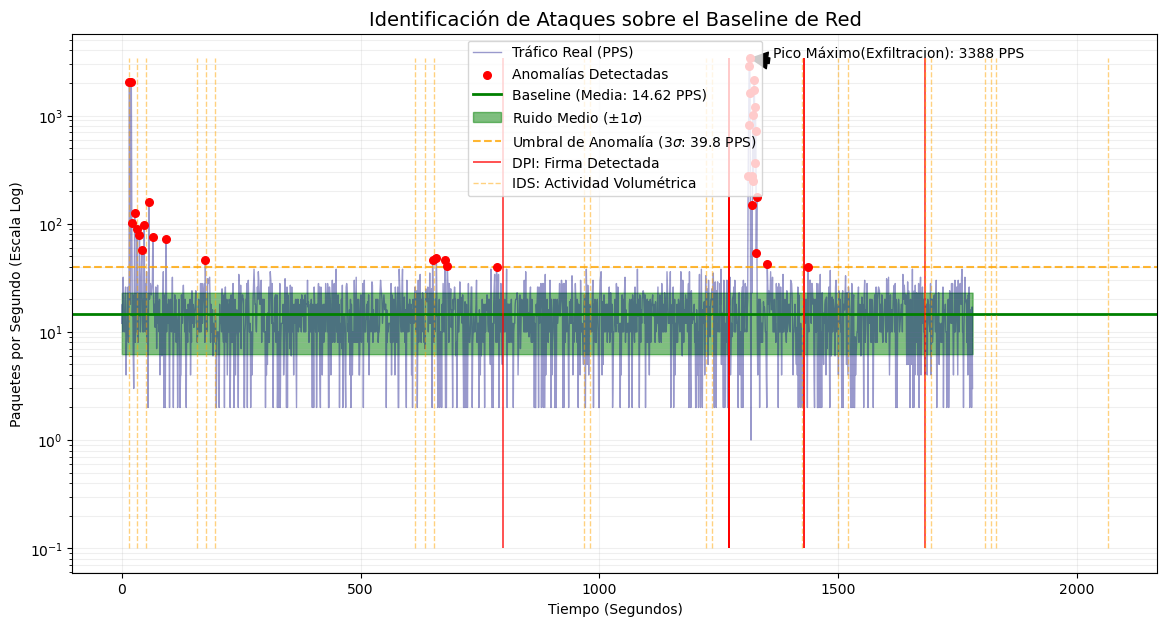

In [11]:
#EL DIBUJO
plt.figure(figsize=(14, 7))

# Pintamos todos los datos de la red (los normales y los ataques)
plt.plot(df_resampled['segundo'], df_resampled['pps'], color='navy', 
         label='Tráfico Real (PPS)', alpha=0.4, linewidth=1)

# Resaltamos los momentos identificados como 'ataques' con puntos rojos
plt.scatter(ataques['segundo'], ataques['pps'], color='red', 
            label='Anomalías Detectadas', zorder=5, s=30)

# Pintamos la Baseline (Media) y el Ruido (Desviación)
plt.axhline(y=media_pps, color='green', linestyle='-', 
            label=f'Baseline (Media: {media_pps:.2f} PPS)', linewidth=2)

# Sombreado de la zona de ruido medio (±1 sigma)
plt.fill_between(df_resampled['segundo'], media_pps - std_pps, media_pps + std_pps, 
                 color='green', alpha=0.5, label='Ruido Medio (±1$\sigma$)')

# Pintamos tu umbral de anomalia (3 sigmas)
plt.axhline(y=umbral_anomalia, color='orange', linestyle='--', 
            label=f'Umbral de Anomalía (3$\sigma$: {umbral_anomalia:.1f} PPS)', alpha=0.8)


# INTRODUZCO EL DF CON LOS TIMES DE LA SONDA
# Filtramos basándonos en el contenido del mensaje
df_dpi = df_sonda[df_sonda['mensaje'].str.contains('DPI|Firma|CRÍTICO', case=False)]
df_vol = df_sonda[~df_sonda['mensaje'].str.contains('DPI|Firma|CRÍTICO', case=False)]

# Líneas ROJAS para firmas críticas (DPI)
plt.vlines(x=df_dpi['relativo_segundos'], ymin=0.1, ymax=pico_max_val, 
           color='red', linestyle='-', alpha=0.8, linewidth=1.2, 
           label='DPI: Firma Detectada')

# Líneas NARANJAS para actividad (Tamaño/Escaneo)
plt.vlines(x=df_vol['relativo_segundos'], ymin=0.1, ymax=pico_max_val, 
           color='orange', linestyle='--', alpha=0.5, linewidth=1, 
           label='IDS: Actividad Volumétrica')


# Usamos escala logarítmica
plt.yscale('log')

# Títulos y etiquetas
plt.title('Identificación de Ataques sobre el Baseline de Red', fontsize=14)
plt.xlabel('Tiempo (Segundos)')
plt.ylabel('Paquetes por Segundo (Escala Log)')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(loc='upper center')

# Anotamos el pico máximo 
pico_max_seg = ataques.loc[ataques['pps'].idxmax(), 'segundo']
pico_max_val = ataques['pps'].max()
plt.annotate(f'Pico Máximo(Exfiltracion): {pico_max_val} PPS', 
             xy=(pico_max_seg, pico_max_val), xytext=(pico_max_seg+50, pico_max_val),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)

plt.show()

In [12]:
'''
 No me cuadra, creo que habría que repetir el experimento bien para que cuadrasen los tiempos. Creo que lance la sonda antes haciendo pruebas y luego puse el tcpdump, crasso error. Creo que el segundo grupo de tres lineas deberían estar donde estan las primeras (alertas) ya que primero hice un escaneo de purbea. Luego puse tcpdump y el segundo escaneo. Luego el primer regustro del pcap es la segunda alerta, está corrido hacia la derecha 
 Vamos a intentar corregirlo, corriendo hacia la derecha. Voy a poner el primer pico para hacerlo coincidir con el de la derecha a ver (el segundo grupo de tres)
 '''
nuevo_offset = 16-615 +16
df_sonda['relativo_segundos'] = ((df_sonda['dt'] - t0_pcap) + pd.Timedelta(seconds=nuevo_offset)).dt.total_seconds()

# Filtramos lo que queda fuera del rango del PCAP para que la gráfica no se vea rara
df_sonda_clean = df_sonda[df_sonda['relativo_segundos'] >= 0]
df_sonda_clean.head(10)

,hora,mensaje,dt,relativo_segundos
6,06:23:34,Actividad interactiva (Shell/Teclado) - Size: 4B,1900-01-01 06:23:34,16.0
7,06:23:54,Actividad interactiva: Posible Escaneo - Ráfag...,1900-01-01 06:23:54,36.0
8,06:24:13,Actividad interactiva: Posible Escaneo - Ráfag...,1900-01-01 06:24:13,55.0
9,06:26:37,[ALERTA DPI] Firma detectada: '.war',1900-01-01 06:26:37,199.0
10,06:29:28,Actividad interactiva (Shell/Teclado) - Size: 3B,1900-01-01 06:29:28,370.0
11,06:29:39,Actividad interactiva (Shell/Teclado) - Size: 3B,1900-01-01 06:29:39,381.0
12,06:33:43,Actividad interactiva (Shell/Teclado) - Size: 8B,1900-01-01 06:33:43,625.0
13,06:33:56,Actividad interactiva (Shell/Teclado) - Size: 6B,1900-01-01 06:33:56,638.0
14,06:34:30,[ALERTA DPI] Firma detectada: 'gcc',1900-01-01 06:34:30,672.0
15,06:34:30,[ALERTA DPI] Firma detectada: 'ptrace',1900-01-01 06:34:30,672.0


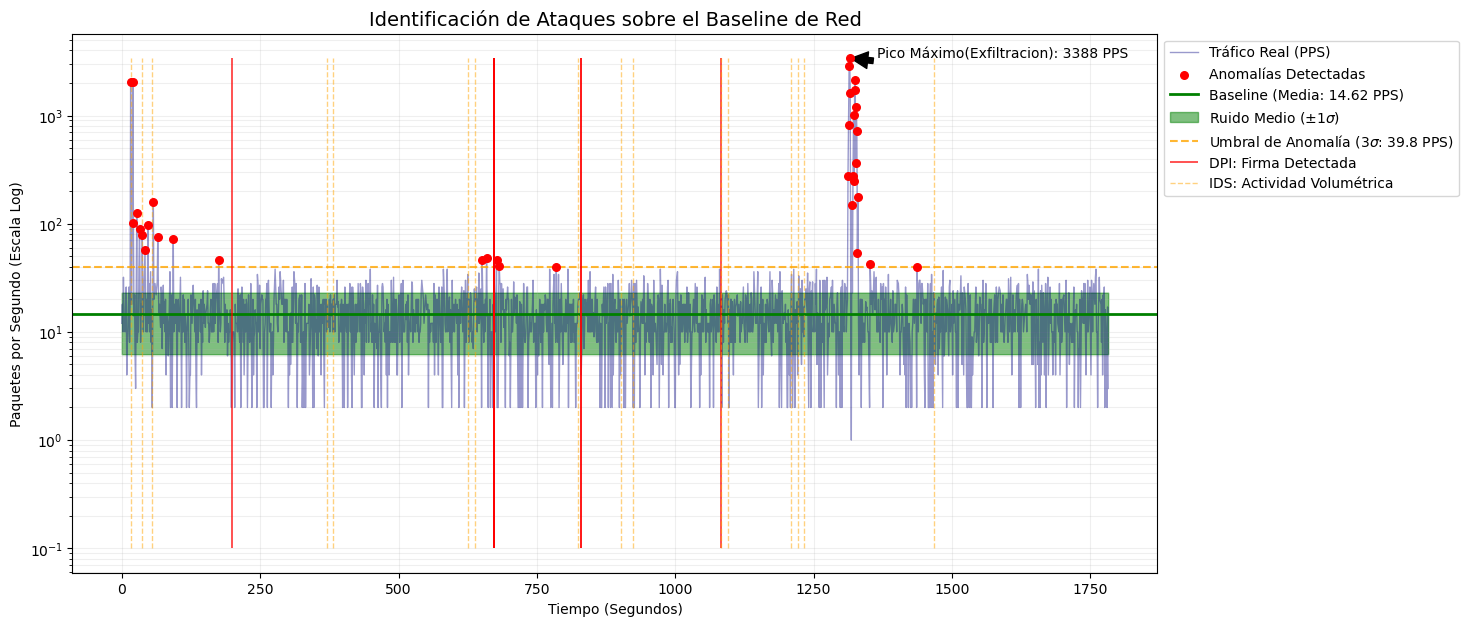

In [13]:
#EL DIBUJO
plt.figure(figsize=(14, 7))

# Pintamos todos los datos de la red (los normales y los ataques)
plt.plot(df_resampled['segundo'], df_resampled['pps'], color='navy', 
         label='Tráfico Real (PPS)', alpha=0.4, linewidth=1)

# Resaltamos los momentos identificados como 'ataques' con puntos rojos
plt.scatter(ataques['segundo'], ataques['pps'], color='red', 
            label='Anomalías Detectadas', zorder=5, s=30)

# Pintamos la Baseline (Media) y el Ruido (Desviación)
plt.axhline(y=media_pps, color='green', linestyle='-', 
            label=f'Baseline (Media: {media_pps:.2f} PPS)', linewidth=2)

# Sombreado de la zona de ruido medio (±1 sigma)
plt.fill_between(df_resampled['segundo'], media_pps - std_pps, media_pps + std_pps, 
                 color='green', alpha=0.5, label='Ruido Medio (±1$\sigma$)')

# Pintamos tu umbral de anomalia (3 sigmas)
plt.axhline(y=umbral_anomalia, color='orange', linestyle='--', 
            label=f'Umbral de Anomalía (3$\sigma$: {umbral_anomalia:.1f} PPS)', alpha=0.8)


# INTRODUZCO EL DF CON LOS TIMES DE LA SONDA
# Filtramos basándonos en el contenido del mensaje
df_dpi = df_sonda_clean[df_sonda_clean['mensaje'].str.contains('DPI|Firma|CRÍTICO', case=False)]
df_vol = df_sonda_clean[~df_sonda_clean['mensaje'].str.contains('DPI|Firma|CRÍTICO', case=False)]

# Líneas ROJAS para firmas críticas (DPI)
plt.vlines(x=df_dpi['relativo_segundos'], ymin=0.1, ymax=pico_max_val, 
           color='red', linestyle='-', alpha=0.8, linewidth=1.2, 
           label='DPI: Firma Detectada')

# Líneas NARANJAS para actividad (Tamaño/Escaneo)
plt.vlines(x=df_vol['relativo_segundos'], ymin=0.1, ymax=pico_max_val, 
           color='orange', linestyle='--', alpha=0.5, linewidth=1, 
           label='IDS: Actividad Volumétrica')


# Usamos escala logarítmica
plt.yscale('log')

# Títulos y etiquetas
plt.title('Identificación de Ataques sobre el Baseline de Red', fontsize=14)
plt.xlabel('Tiempo (Segundos)')
plt.ylabel('Paquetes por Segundo (Escala Log)')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)

# Anotamos el pico máximo 
pico_max_seg = ataques.loc[ataques['pps'].idxmax(), 'segundo']
pico_max_val = ataques['pps'].max()
plt.annotate(f'Pico Máximo(Exfiltracion): {pico_max_val} PPS', 
             xy=(pico_max_seg, pico_max_val), xytext=(pico_max_seg+50, pico_max_val),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)

plt.show()

# Conclusiones del Análisis Forense: Correlación de la Intrusión

###  Metodología Aplicada
Para este análisis, se ha implementado un modelo de **detección híbrida**:
1.  **Análisis Estadístico (Volumetría):** Establecimiento de un *baseline* de tráfico normal y detección de anomalías mediante el umbral de confianza $3\sigma$ (99.7% de probabilidad estadística).
2.  **Inspección Profunda de Paquetes (DPI):** Uso de firmas específicas para identificar la naturaleza exacta de la amenaza en el payload de los paquetes capturados.

### 🛡️ Cronología de la Kill Chain (Cadena de Ataque)
La integración de los logs de la sonda sobre la telemetría del PCAP permite reconstruir el ataque paso a paso:
* **1. Escaneo Inicial (nmap)**: Alertas basadas en actividad interactiva correspondientes al primer pico del escaneo. El número de paquetes obtenidos por la sonda es sustancialmente menor que los obtenidos en el análisis estadístico, ya que descartamos la mayoría (muchos de los paquetes del handshake de nmap van vacío con lo cual la sonda los descarta)
* **2. Acceso Inicial (`.war`)**: 
    * *Evidencia:* Primera alerta crítica de DPI. 
    * *Descripción:* El atacante planta su primer pie en el servidor explotando una vulnerabilidad en el servidor de aplicaciones Java (Tomcat/JBoss) para subir un artefacto malicioso.
* **3. Preparación y Movimiento Lateral (descarga `.c`)**: 
    * *Evidencia:* Actividad interactiva detectada por volumetría de payloads pequeños.
    * *Descripción:* Fase de reconocimiento y transferencia de herramientas. El atacante descarga el código fuente del exploit en C para preparar la escalada local.
* **4. Escalada de Privilegios (`gcc` / compilación)**: 
    * *Evidencia:* Patrón de ráfagas interactivas (compilación local).
    * *Descripción:* El actor utiliza las herramientas del sistema para compilar el exploit. La amenaza transiciona de un vector externo a un riesgo de ejecución de código interno.
* **5. Compromiso Total del Sistema (`firefart`)**: 
    * *Evidencia:* Alertas de DPI finales y picos de tráfico de exfiltración.
    * *Descripción:* El exploit *DirtyCow* se ejecuta con éxito, permitiendo la creación de un usuario con privilegios de `root`. El atacante obtiene el control total de la máquina víctima.
* **6. Omisión de exflitración**: Después de completar la escalada vemos alertas volumétricas correspondientes a la interacción con la víctima y a la exploración, detección y preparación de los datos para la posterior exfiltración.



### Comentarios
* **Sincronización Multicapa:** Se ha realizado una correlación temporal precisa entre fuentes de datos heterogéneas (PCAP en formato Unix Epoch vs. Logs de Sonda en tiempo real).
* **Reducción de Falsos Positivos:** El uso de una escala logarítmica y bandas de ruido permite ignorar el tráfico de mantenimiento y centrar la respuesta de incidentes exclusivamente en eventos de alta densidad y riesgo.